In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import datasets
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, IterableDataset, get_worker_info
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

/home/rianbutala/projects/wm1/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = datasets.load_dataset("mvp-lab/LLaVA-OneVision-1.5-Mid-Training-85M", streaming=True)

In [3]:
# type(next(iter(dataset['train']['image'])))
# PIL.PngImagePlugin.PngImageFile

In [4]:
transform = transforms.Compose([
  transforms.Resize((256,256)),
  transforms.PILToTensor(),
  transforms.ConvertImageDtype(torch.float32)
])

# class ImageDataset(Dataset):
#   def __init__(self,dataset, transform=None):
#     super().__init__()
#     self.transform=transform
#     self.dataset = dataset
#     self.dataset_iter = iter(self.dataset['train']['image'])

#   def __len__(self):
#     return int(1e10)

#   def __getitem__(self,idx):
#     try:
#       next_img = next(self.dataset_iter)
#     except StopIteration:
#       self.dataset_iter = iter(self.dataset['train']['image'])
#       next_img = next(self.dataset_iter)

#     return self.transform(next_img)
class ImageDataset(IterableDataset):
  def __init__(self,dataset, transform=None):
    super().__init__()
    self.dataset = dataset
    self.transform = transform
    
  def __iter__(self):
    stream = self.dataset
    info=get_worker_info()
    if info is not None:
      stream = stream.shard(num_shards=info.num_workers, index=info.id)
    for item in stream:
      yield self.transform(item['image'].convert("RGB"))
  

In [5]:
ds=ImageDataset(dataset['train'], transform)
loader=DataLoader(ds,batch_size=32,num_workers=4)

In [6]:
# next(iter(loader)).shape
# torch.Size([1, 3, 256, 256])

<h3> btw </h3>
<p> scaling_factor is the patch size, and seq_len is the number of patches

In [7]:
def patchify(tensor, seq_len):
  # takes tensor of b,c,h,w
  # returns b,s,c tensor
  B, C, H, W = tensor.shape
  assert H==W # square patch
  assert int(seq_len**0.5) ** 2 == seq_len
  assert (H*W)%seq_len ==0

  scaling_factor = int(H/(seq_len**0.5))
  tensor = tensor.reshape(B,C,H//scaling_factor, scaling_factor, W//scaling_factor,scaling_factor)
  tensor = tensor.permute(0,2,4,1,3,5)
  tensor = tensor.reshape(B, H//scaling_factor* W//scaling_factor, C*scaling_factor*scaling_factor)
  return tensor

def unpatchify(tensor,height):
  # assume h,w is the same
  width=height
  B, S, C = tensor.shape
  scaling_factor = int(height/(S**0.5))
  # tensor shape as it stands: b, h//scf * w//scf, c*scf*scf
  image_c = C//scaling_factor//scaling_factor
  tensor = tensor.reshape(B,height//scaling_factor,width//scaling_factor,image_c,scaling_factor,scaling_factor)
  tensor = tensor.permute(0,3,1,4,2,5)
  # b,c,h//scf,scf,w//scf,scf
  tensor = tensor.reshape(B,image_c,height,width)
  return tensor

example = torch.rand(1,3,256,256)
print(f"patch: {patchify(example, seq_len=256).shape}")
print(f"unpatch: {unpatchify(patchify(example,seq_len=256),height=256).shape}")
  

patch: torch.Size([1, 256, 768])
unpatch: torch.Size([1, 3, 256, 256])


In [8]:
class Block(nn.Module):
  def __init__(self,nhead=4,seq=256,emb=768):
    super().__init__()
    self.seq=seq
    self.emb=emb
    self.nhead=nhead
    assert emb%nhead==0

    self.ln1 = nn.LayerNorm(emb)
    self.qkv_proj = nn.Linear(emb,emb*3)
    self.o_proj = nn.Linear(emb,emb)

    self.ln2 = nn.LayerNorm(emb)
    self.mlp = nn.Sequential(
      nn.Linear(emb,emb*4),
      nn.GELU(),
      nn.Linear(emb*4,emb)
    )
    
  def forward(self,x):
    # x shape b,s,c
    b,s,c=x.shape
    # x = self.ln1(x)
    qkv=self.qkv_proj(self.ln1(x))
    q,k,v = qkv.chunk(3,dim=-1)
    q = q.view(b,s,self.nhead,c//self.nhead).transpose(2,1)
    k = k.view(b,s,self.nhead,c//self.nhead).transpose(2,1)
    v = v.view(b,s,self.nhead,c//self.nhead).transpose(2,1)

    attn_out = F.scaled_dot_product_attention(q,k,v)
    attn_out = attn_out.transpose(2,1).contiguous().reshape(b,s,c)
    attn_out = self.o_proj(attn_out)
    # x += attn_out
    x = x+attn_out

    # x += self.mlp(self.ln2(x))
    x = x+self.mlp(self.ln2(x))

    return x

class Encoder(nn.Module):
  # todo add positional embeddings and maybe patch embeddings idk
  # todo add layer norm
  def __init__(self,nlayer=4,nhead=4,seq=256,emb=768):
    super().__init__()
    self.blocks=nn.ModuleList([Block(nhead,seq,emb) for _ in range(nlayer)])
    self.ln_out = nn.LayerNorm(emb)

  def forward(self,x):
    # pos_emb = embed(context_indices)
    # x+=pos_emb
    for block in self.blocks:
      x = block(x)

    return self.ln_out(x)

class Predictor(nn.Module):
  def __init__(self,nlayer=4,nhead=4,seq=256,emb=768,dim=384):
    super().__init__()
    self.blocks=nn.ModuleList([Block(nhead,seq,dim) for _ in range(nlayer)]) #normally head,seq,emb but we downcast
    # self.register_buffer("emb_idx", torch.arange(0,seq))
    self.down=nn.Linear(emb,dim)
    self.up=nn.Linear(dim,emb)
    self.ln_out = nn.LayerNorm(emb)
    
  def forward(self,x):
    # print("predictor forward")
    x = self.down(x)
    # print("down")
    # pos_emb = embed(self.emb_idx)
    # x+=pos_emb
    # print("start loop")
    for block in self.blocks:
      # print("loop")
      x = block(x)

    # print("loop done")
    x = self.up(x)
    # print("up")
    return self.ln_out(x)

# quick warning for anyone reading this with their own human eyes: yes i know all the variables have the wrong names no i will not change it
class InformedPredictor(nn.Module):
  def __init__(self,seq=256,emb=768,masked_tokens=10):
    super().__init__()
    self.encoder = Encoder(seq=seq,emb=emb)
    self.target_encoder = Encoder(seq=seq,emb=emb)
    self.predictor = Predictor(seq=seq,emb=emb)
    assert masked_tokens <= seq
    self.seq=seq
    self.emb=emb
    self.masked_tokens=masked_tokens
    self.embed_mlp = nn.Sequential(
      nn.LayerNorm(emb),
      nn.Linear(emb,emb),
    )
    self.embed = nn.Embedding(seq,emb)
    nn.init.trunc_normal_(self.embed.weight, std=.02)
    self.register_buffer("pos_idx", torch.arange(0,seq))
    # self.register_buffer("mask_token_embedding", torch.ones(self.masked_tokens,emb))
    self.mask_token_embedding = nn.Parameter(torch.randn(1,emb))

    self.target_encoder.load_state_dict(self.encoder.state_dict())
    for p in self.target_encoder.parameters():
      p.requires_grad = False

  def forward(self,x):
    x = patchify(x,self.seq)
    b,s,c = x.shape
    # x += self.embed(self.pos_idx)
    x = self.embed_mlp(x)
    x = x+self.embed(self.pos_idx)
    x_orig = x.clone()
    # b,256,768 for ex.

    # inv_masked_token_idx = torch.randint(0,self.seq,torch.Size([self.seq-self.masked_tokens]))
    # inv_masked_token_idx = torch.randperm(self.seq-self.masked_tokens)
    all_perms = torch.randperm(self.seq, device=x.device)
    inv_masked_token_idx = all_perms[:self.seq-self.masked_tokens]
    filtered_x =x [:,inv_masked_token_idx,:]

    encoded_x = self.encoder(filtered_x) #b,seq-mask,c
    mask = torch.isin(self.pos_idx,inv_masked_token_idx) # which elements of inv masked token idx in pos idx
    mask_token_idx = self.pos_idx[~mask]
    mask_tokens = self.embed(mask_token_idx).unsqueeze(0).expand(b,-1,-1)
    mask_tokens = mask_tokens+self.mask_token_embedding.unsqueeze(0).expand(b,self.masked_tokens,-1)

    # print(f"sanity: {encoded_x.shape, mask_tokens.shape}")
    predicted_x = self.predictor(torch.cat([encoded_x,mask_tokens],dim=1)) # b,s,c
    with torch.no_grad():
      encoded_x = self.target_encoder(x_orig)

    mask_pred = predicted_x[:,self.seq-self.masked_tokens:,:]
    target_pred = encoded_x[:,mask_token_idx,:]
    return mask_pred, target_pred


In [9]:
with torch.no_grad():
  jepa=InformedPredictor()
  out, filtered_out = jepa(example)
  print(out.shape,filtered_out.shape)

  enc=Encoder()
  print(enc(patchify(example,256)).shape)
  # enc(filtered_out).shape

torch.Size([1, 10, 768]) torch.Size([1, 10, 768])
torch.Size([1, 256, 768])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.autograd.set_detect_anomaly(True, check_nan=False)
model = InformedPredictor().to(device)
loss_fn = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

steps = 10000
ema_beta = 0.999
dl_iter = iter(loader)
pbar = tqdm(total=steps)
# for step in tqdm(range(steps)):
for step in range(steps):
  try:
    data = next(dl_iter).to(device)
    # data = torch.randn((1,3,256,256))
  except StopIteration:
    dl_iter = iter(loader)
    data = next(dl_iter).to(device)

  mask_pred, target_pred = model(data)
  loss = loss_fn(mask_pred, target_pred)
  # print(f"loss: {loss.item()}")
  loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  pbar.update(1)
  pbar.set_postfix(loss=loss.item())


  for param, reference in zip(model.target_encoder.parameters(), model.encoder.parameters()):
    param.data.mul_(ema_beta).add_(reference.data, alpha=1-ema_beta)

  0%|          | 36/10000 [02:17<46:26,  3.58it/s, loss=0.725]   

In [ ]:
print(f"ctx encoder params {sum([p.numel() for p in model.encoder.parameters()])/1_000_000:.2f}m params")
print(f"target encoder params {sum([p.numel() for p in model.target_encoder.parameters()])/1_000_000:.2f}m params")
print(f"predictor params {sum([p.numel() for p in model.predictor.parameters()])/1_000_000:.2f}m params")
print(f"embedding params {sum([p.numel() for p in model.embed.parameters()])/1_000_000:.2f}m params")

ctx encoder params 28.35m params
target encoder params 28.35m params
predictor params 7.69m params
embedding params 0.20m params


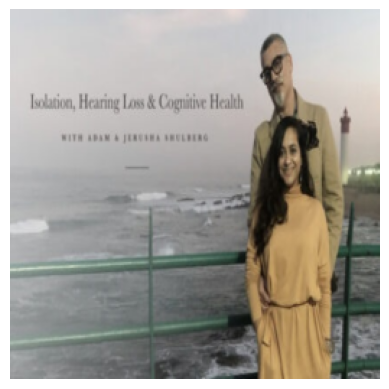

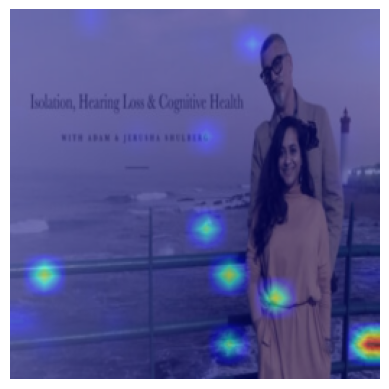

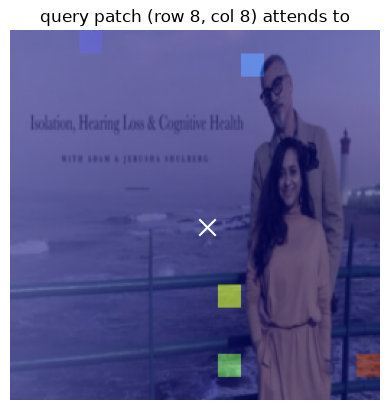

In [ ]:
@torch.no_grad()
def get_attn_maps(x):
  maps = []
  for block in model.encoder.blocks:
    b,s,c =x.shape
    h = block.nhead
    q,k,v = block.qkv_proj(block.ln1(x)).chunk(3,dim=-1)
    q = q.view(b,s,h,c//h).transpose(1,2)
    k = k.view(b,s,h,c//h).transpose(1,2)
    v = v.view(b,s,h,c//h).transpose(1,2)# b,h,s,c//h
    weights = (q@k.transpose(-2,-1)) / (c//h)**0.5 # b,h,s,s
    weights = weights.softmax(dim=-1)
    maps.append(weights[0].cpu().detach())
    out = (weights@v).transpose(1,2).reshape(b,s,c)
    x = x+block.o_proj(out)
    x = x+block.mlp(block.ln2(x))
  return maps

    
# plt.imshow(data.detach().cpu().squeeze(0).permute(1,2,0).numpy())
model.eval()
img = data.to(device)
# x = patchify(img,seq_len=model.seq) + model.embed(model.pos_idx)
x = patchify(img,seq_len=model.seq)
x = model.embed_mlp(x)
x = x + model.embed(model.pos_idx)
maps = get_attn_maps(x)

# from here on out is between claude opus and god alone. i could not possibly tell you what this means

g = int(model.seq**0.5) # 16
heat = maps[-1].mean(0).mean(0).reshape(g,g)
heat = F.interpolate(heat[None,None], size=(256,256), mode="bilinear")[0,0]

plt.imshow(data.squeeze(0).cpu().permute(1,2,0).numpy());plt.axis("off");plt.show()
plt.imshow(img[0].cpu().permute(1,2,0).numpy())
plt.imshow(heat.cpu().numpy(),cmap='jet',alpha=0.5)
plt.axis("off"); plt.show()

# single-query attention: where does ONE patch look? this IS content-dependent, unlike the
# query-AVERAGED map above (which is mostly positional and looks ~the same for every image).
qy, qx = g//2, g//2                          # center patch on the 16x16 grid (row, col)
qi = qy*g + qx                               # patchify flattens row-major: idx = row*g + col
qmap = maps[-1].mean(0)[qi].reshape(g,g)     # row qi = what query patch qi attends TO, avg over heads
qmap = F.interpolate(qmap[None,None], size=(256,256), mode="nearest")[0,0]
plt.imshow(img[0].cpu().permute(1,2,0).numpy())
plt.imshow(qmap.cpu().numpy(), cmap='jet', alpha=0.5)
plt.scatter([qx*16+8],[qy*16+8], c='white', s=140, marker='x')   # mark the query patch
plt.title(f"query patch (row {qy}, col {qx}) attends to"); plt.axis("off"); plt.show()

data = next(dl_iter).to(device)

In [ ]:
# straight clauded it

# ---- linear probe: is the encoder actually useful? ----
# Freeze the encoder, extract mean-pooled patch features, fit a linear classifier
# on CIFAR-10. Three rows so you can isolate the ENCODER's contribution:
#   embed-only  = patch-embed features, NO encoder blocks   (baseline floor)
#   random-init = random encoder blocks on top of embed
#   pretrained  = trained encoder blocks on top of embed
# pretrained - embed-only = what the encoder actually adds. If random-init ~= embed-only,
# the "random" number is really just the (trained, shared) patch-embed talking.
probe_tf = transforms.Compose([
  transforms.Resize((256,256)),
  transforms.PILToTensor(),
  transforms.ConvertImageDtype(torch.float32),
])
cifar_train = torchvision.datasets.CIFAR10("./data", train=True,  download=True, transform=probe_tf)
cifar_test  = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=probe_tf)

n_train, n_test = 3000, 5000  # bigger test set -> SE ~0.7% (was ~1.5%), so small gaps become real
train_idx = torch.randperm(len(cifar_train))[:n_train]
test_idx  = torch.randperm(len(cifar_test))[:n_test]

@torch.no_grad()
def extract_features(encoder, dataset, idx, bs=64):
  if encoder is not None: encoder.eval()
  feats, labels = [], []
  for i in range(0, len(idx), bs):
    batch = [dataset[j] for j in idx[i:i+bs].tolist()]
    imgs = torch.stack([b[0] for b in batch]).to(device)
    ys   = torch.tensor([b[1] for b in batch])
    x = model.embed_mlp(patchify(imgs, model.seq)) + model.embed(model.pos_idx)  # patch-embed + pos-emb, as forward()
    z = x.mean(1) if encoder is None else encoder(x).mean(1)     # encoder=None -> embed-only floor
    feats.append(z.cpu()); labels.append(ys)
  return torch.cat(feats), torch.cat(labels)

def run_probe(encoder, tag):
  Xtr, ytr = extract_features(encoder, cifar_train, train_idx)
  Xte, yte = extract_features(encoder, cifar_test,  test_idx)
  mu, sd = Xtr.mean(0), Xtr.std(0) + 1e-6                        # standardize features
  Xtr, Xte = ((Xtr - mu) / sd).to(device), ((Xte - mu) / sd).to(device)
  ytr = ytr.to(device)
  clf = nn.Linear(Xtr.shape[1], 10).to(device)
  opt = optim.AdamW(clf.parameters(), lr=1e-3, weight_decay=1e-4)
  for _ in range(200):                                          # full-batch logistic regression
    opt.zero_grad()
    F.cross_entropy(clf(Xtr), ytr).backward()
    opt.step()
  with torch.no_grad():
    acc = (clf(Xte).argmax(1).cpu() == yte).float().mean().item()
  print(f"{tag:>12}: linear-probe test acc = {acc*100:5.1f}%   (chance = 10%)")
  return acc

run_probe(None,                 "embed-only")   # floor: patch-embed alone, no encoder blocks
run_probe(Encoder().to(device), "random-init")  # random blocks on top of the same embed
run_probe(model.encoder,        "pretrained")   # trained blocks on top -- gap over embed-only = real value

  embed-only: linear-probe test acc =  26.9%   (chance = 10%)
 random-init: linear-probe test acc =  33.9%   (chance = 10%)
  pretrained: linear-probe test acc =  27.7%   (chance = 10%)


0.2773999869823456

explained variance (top 8): ['0.61', '0.24', '0.10', '0.02', '0.01', '0.01', '0.00', '0.00']


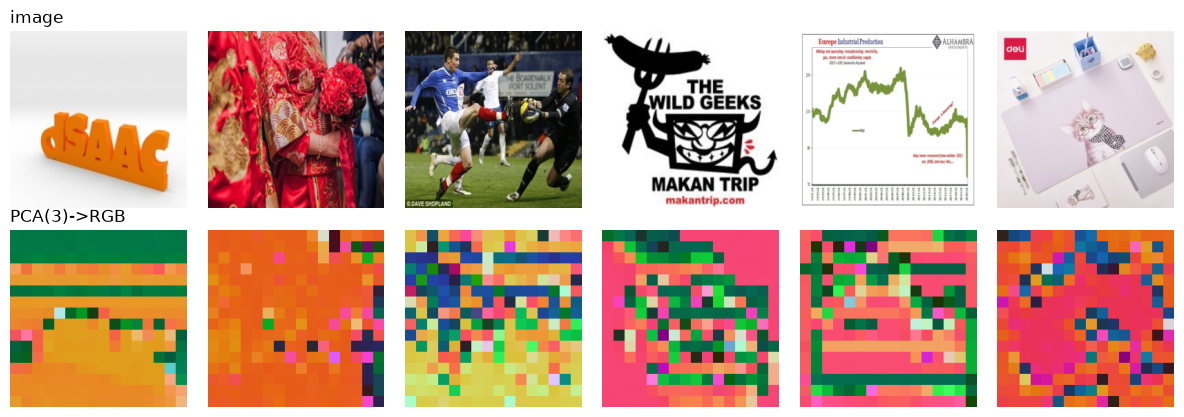

In [ ]:
# ---- PCA feature maps (DINO-style) ----
# Per-patch 768-d embeddings -> top PCA components -> RGB -> 16x16 patch grid.
# Coherent colored blobs => the encoder groups semantically-similar regions.
# NOTE: per-dim whitening stops any single high-variance dim from dominating PCA.
# With the encoder's final LayerNorm now in place the outlier-dim hijack is gone,
# so PC1 is usually real content -> drop_first defaults to False (flip to compare).

n_imgs = 6
it = iter(loader)
imgs = torch.cat([next(it) for _ in range(n_imgs)], dim=0).to(device)  # (n,3,256,256)

model.eval()
with torch.no_grad():
  x = model.embed_mlp(patchify(imgs, model.seq)) + model.embed(model.pos_idx)  # patch-embed + pos-emb, exactly as forward()
  emb = model.target_encoder(x)                               # (n, S, D)
n, S, D = emb.shape
g = int(S**0.5)  # 16

flat = emb.reshape(-1, D)
flat = (flat - flat.mean(0, keepdim=True)) / (flat.std(0, keepdim=True) + 1e-6)  # per-dim whiten

_, Sv, V = torch.pca_lowrank(flat, q=8)
evr = (Sv**2) / (Sv**2).sum()
print("explained variance (top 8):", [f"{e:.2f}" for e in evr.tolist()])

drop_first = False                                 # with final LN, PC1 is usually content; set True to drop it
comps = slice(1, 4) if drop_first else slice(0, 3)
proj = flat @ V[:, comps]                                            # (n*S, 3)
proj = (proj - proj.amin(0)) / (proj.amax(0) - proj.amin(0) + 1e-6)  # -> [0,1] per channel
proj = proj.reshape(n, g, g, 3).cpu()

fig, axes = plt.subplots(2, n_imgs, figsize=(2*n_imgs, 4.2))
for i in range(n_imgs):
  axes[0, i].imshow(imgs[i].cpu().permute(1, 2, 0).numpy()); axes[0, i].axis("off")
  pca_map = F.interpolate(proj[i].permute(2, 0, 1)[None], size=(256, 256), mode="nearest")
  axes[1, i].imshow(pca_map[0].permute(1, 2, 0).numpy()); axes[1, i].axis("off")
axes[0, 0].set_title("image", loc="left"); axes[1, 0].set_title("PCA(3)->RGB", loc="left")
plt.tight_layout(); plt.show()